# Visualizing Commonality

1. Load Fusion files of all subjects
2. Make mask-image based on highest commonality coefficitiens (with a certain % threshold)
3. Sum the subject-specific mask images to visuales location of highest commonalities 

In [1]:
import sys
sys.path.append('/home/reabt/experiments/ncc/MRI/code/')

from glob import glob

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from nilearn import plotting
from nilearn.image import new_img_like
from scipy.ndimage import label

from utils.load_cfg import load_fusion_config_instance
from utils.subj import *

## Function to create the masks and plot the data

In [2]:
def _get_mappable(max):
    norm = mpl.colors.Normalize(vmin=0,vmax=max)
    return plt.cm.ScalarMappable(cmap='inferno', norm=norm)


def plot_commonality(fusionFiles, modality, thres, time, mask):
    n_slices = 8
    fig, axes = plt.subplots(ncols=1, nrows=len(time), figsize=(7, 3)) # , subplot_kw={'projection': '3d'})

    for n, t in enumerate(time):
        print(t)
        times = np.arange(-1000, 1000, 10)
        subj_mask_data = []

        for file in fusionFiles[:1]:

            fusion = joblib.load(file)
            t_data = fusion['data'][t][modality] #fusion data of time point 130 for current modality
            fusion_idx = fusion['voxel_index_py']

            data_1d = np.zeros(mask.shape).flatten()
            data_1d[fusion_idx] = t_data
            data_3d = data_1d.reshape(mask.shape)
            threshold = np.nanpercentile(t_data, thres)

            tmp_mask_img = np.zeros(mask.shape)
            tmp_mask_img[data_3d > threshold] = 1
            subj_mask_data.append(tmp_mask_img)

        subj_mask_array = np.sum(np.array(subj_mask_data), axis=0)
        subj_mask_img = new_img_like(mask, subj_mask_array)

 
        display = plotting.plot_stat_map(
            subj_mask_img, 
            colorbar=True, 
            threshold=threshold,
            cut_coords=8,
            display_mode='z', 
            draw_cross=False, 
            # title=f'time: {times[t]} ms',
            figure=fig,
            cmap='inferno',
            black_bg=False, 
            annotate=False,
            axes=axes[n]
        )
        axes[n].set_title(times[t])
        axes[n].title.set_horizontalalignment('left')
    # fig.subplots_adjust(right=0.8)
    # cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    plt.colorbar(display, ax=axes, orientation='vertical')
    plt.suptitle(modality, y=1.05)
    plt.show()
    # return display


## Get all filesnames

In [6]:
config_class_name = 'FusionConfig_C5'
thres = 0.1
meanMEG = False
cfg = load_fusion_config_instance(config_class_name) # since no subject ID is specified, '*' will be used --> creates pattern with subject-wildcard instead of subject filename 

if meanMEG:
    fusionFiles = sorted(glob(cfg.get_outFile_names()['fusion_mean_pkl']))
else:  
    fusionFiles = sorted(glob(cfg.get_outFile_names()['fusion_pkl']))

fusionFiles

full_data=[]

for file in fusionFiles:
    fusion = joblib.load(file)
    full_data.append(fusion)


No subjectID specified. Returning mask of subject "19910823ssld" as default

No subjectID specified. Returning mask of subject "19910823ssld" as default


## Do the plotting

### 1. Sensory

In [5]:
modality = 'sensory'  # 'sensory' or 'suprasensory'
thres = 90
time = np.arange(0, 200, 1)
mask = nib.load(cfg.maskFile)
# figs = []
# displays = []

# plot_commonality(fusionFiles, modality, thres, time, mask)


In [ ]:
time = np.arange(0, 200, 1)
fusion_data={}
for m, modality in enumerate(ALL_MODELS):
    print(modality)
    data=[]
    for n, t in enumerate(time):
        # print(t)
        subj_mask_data = []

        for fusion in full_data:
            t_data = fusion['data'][t][modality] #fusion data of time point 130 for current modality
            fusion_idx = fusion['voxel_index_py']

            data_1d = np.zeros(mask.shape).flatten()
            data_1d[fusion_idx] = t_data
            data_3d = data_1d.reshape(mask.shape)
            threshold = np.nanpercentile(t_data, thres)

            tmp_mask_img = np.zeros(mask.shape)
            tmp_mask_img[data_3d > threshold] = 1
            subj_mask_data.append(tmp_mask_img)

        subj_mask_array = np.sum(np.array(subj_mask_data), axis=0)
        subj_mask_img = new_img_like(mask, subj_mask_array)
        data.append(subj_mask_img)
    fusion_data[modality]=data


In [7]:
from copy import deepcopy

In [ ]:
# modality = 'sensory'  # 'sensory' or 'suprasensory'
thres = 90
time = [125, 130]
mask = nib.load(cfg.maskFile)
times = np.arange(-1000, 1000, 10)
cols = ALL_MODELS
rows = [str(t) for t in times[time]]


125
130
125
130


<bound method Figure.show of <Figure size 2000x600 with 36 Axes>>

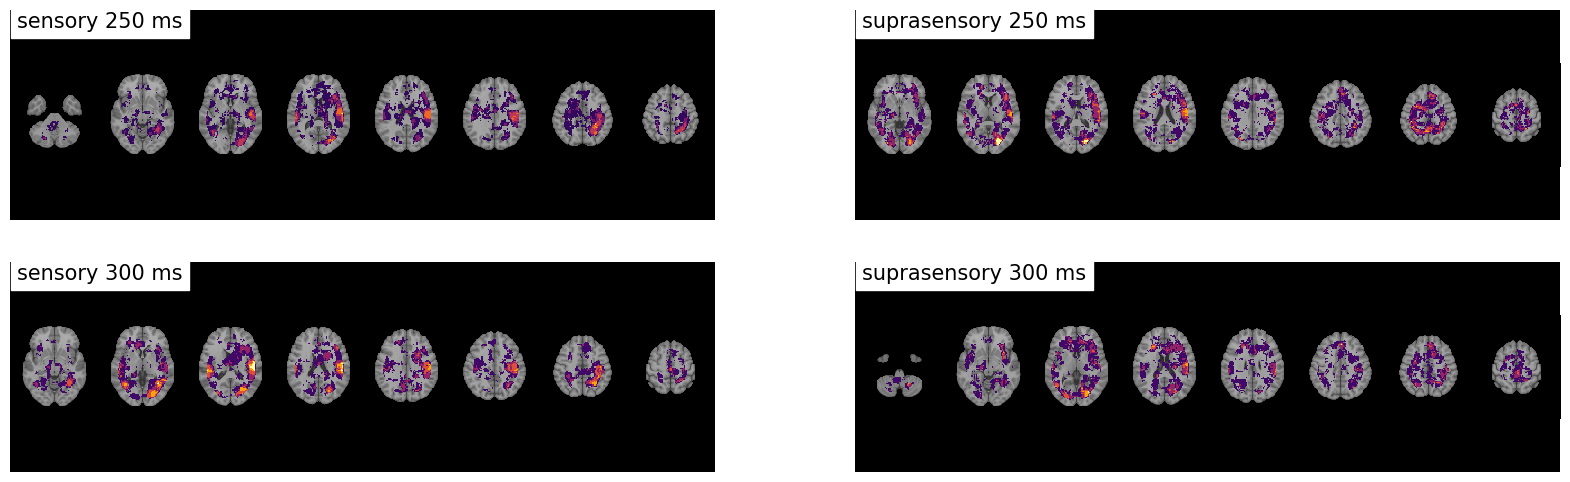

In [11]:

thres = 90
time = [125, 130]
mask = nib.load(cfg.maskFile)
times = np.arange(-1000, 1000, 10)
cols = ALL_MODELS
rows = [str(t) for t in times[time]]

plt.close()

fig, axes = plt.subplots(ncols=2, nrows=len(time), figsize=(20,6)) # , subplot_kw={'projection': '3d'})

for m, modality in enumerate(ALL_MODELS):
    for n, t in enumerate(time):
        print(t)

        subj_mask_img = fusion_data[modality][t]

        plotting.plot_stat_map(
            subj_mask_img, 
            colorbar=False, 
            threshold=threshold,
            cut_coords=8,
            display_mode='z', 
            draw_cross=False, 
            figure=fig,
            cmap='inferno',
            black_bg=True, 
            annotate=False,
            axes=axes[n, m],
            title = f"{modality} {(t-100)*10} ms"
        )
fig.show
# fig_original=deepcopy(fig)
# axes_original=deepcopy(axes)

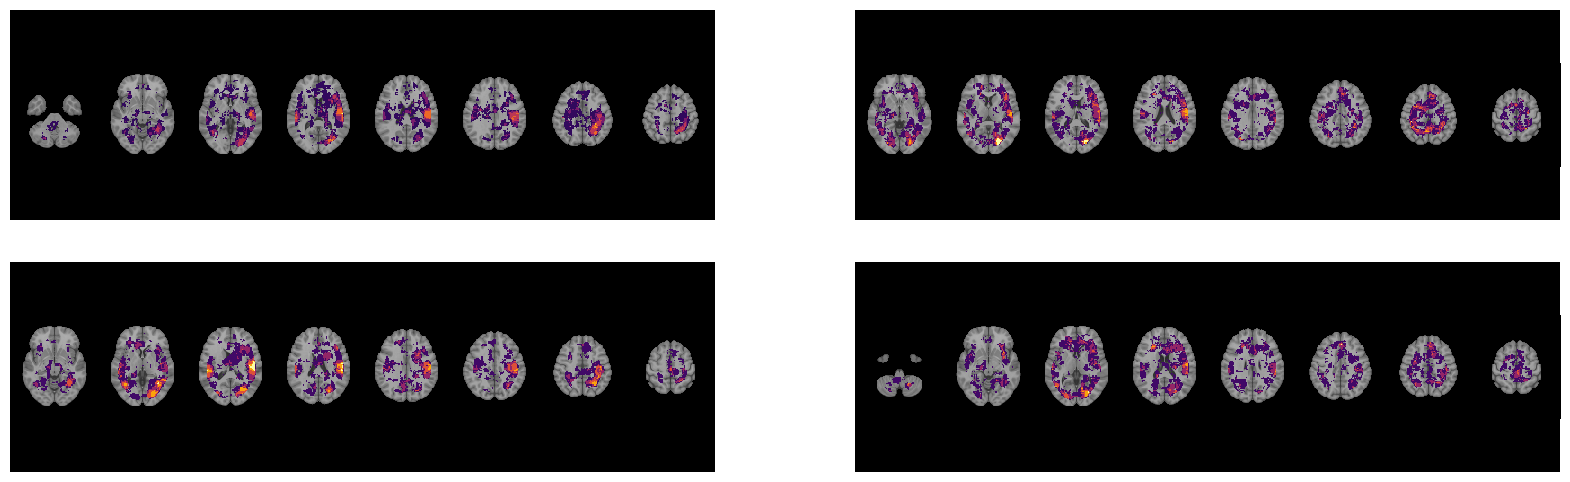

In [ ]:
fig1 = deepcopy(fig)
# # fig1.subplots_adjust(top=0.1)

# fig1.axes[0].spines['top'].set_visible(False)
# fig1.tight_layout()
# fig1
# # dir(axes1[0,0])


In [131]:
dir(axes1[0,0])

['ArtistList',
 '_AxesBase__clear',
 '_PROPERTIES_EXCLUDED_FROM_SET',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_text',
 '_adjustable',
 '_agg_filter',
 '_alias_map',
 '_alpha',
 '_anchor',
 '_animated',
 '_aspect',
 '_autotitlepos',
 '_axes',
 '_axes_locator',
 '_axis_map',
 '_axis_names',
 '_axisbelow',
 '_box_aspect',
 '_callbacks',
 '_check_no_units',
 '_children',
 '_clipon',
 '_clippath',
 '_cm_set',
 '_colorbars',
 '_convert_dx',
 '_current_image',
 '_different_canvas',
 '_errorevery_to_mask',
 '_facecolor',
 '_fill_between_process_units',
 '_fill_between_x_or_y',
 '_forward_navigation_events',
 '_

# This type of updating works!!!

['ArtistList', '_AxesBase__clear', '_PROPERTIES_EXCLUDED_FROM_SET', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_add_text', '_adjustable', '_agg_filter', '_alias_map', '_alpha', '_anchor', '_animated', '_aspect', '_autotitlepos', '_axes', '_axes_locator', '_axis_map', '_axis_names', '_axisbelow', '_box_aspect', '_callbacks', '_check_no_units', '_children', '_clipon', '_clippath', '_cm_set', '_colorbars', '_convert_dx', '_current_image', '_different_canvas', '_errorevery_to_mask', '_facecolor', '_fill_between_process_units', '_fill_between_x_or_y', '_forward_navigation_events', '_frameon', '_fully_clipped_to_axes', '_gci', '_gen_axes_patch',

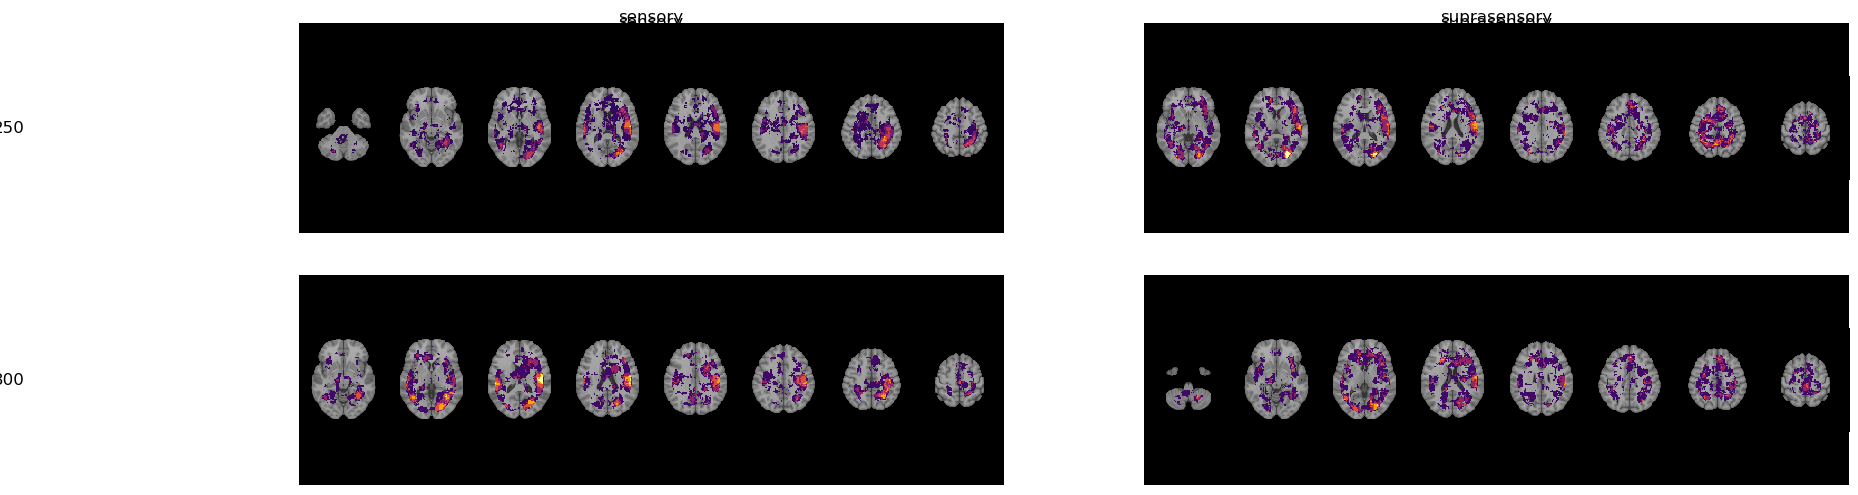

In [147]:
axes1 = deepcopy(axes)
for ax, col in zip(axes1[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='center')
    print(dir(ax))

for ax, row in zip(axes1[:,0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='left', va='center')
fig2 = axes1[0,0].figure
# fig2.subplots_adjust(top=0.85, right=8)
fig2

In [139]:
dir(axes1[0,0].xaxis)

['OFFSETTEXTPAD',
 '_PROPERTIES_EXCLUDED_FROM_SET',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__name__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_agg_filter',
 '_alpha',
 '_animated',
 '_autolabelpos',
 '_autoscale_on',
 '_axes',
 '_callbacks',
 '_clipon',
 '_clippath',
 '_cm_set',
 '_converter',
 '_converter_is_explicit',
 '_copy_tick_props',
 '_different_canvas',
 '_format_with_dict',
 '_fully_clipped_to_axes',
 '_get_autoscale_on',
 '_get_axis_name',
 '_get_shared_axes',
 '_get_shared_axis',
 '_get_tick',
 '_get_tick_boxes_siblings',
 '_get_tick_label_size',
 '_get_ticklabel_bboxes',
 '_get_ticks_position',
 '_gid',
 '_in_layout',
 '_init',
 '_internal_update',
 '_label',
 '_majo

In [ ]:
fig1.axes[7].fill('red')
fig1

In [ ]:
ig1.axes[7].fill('red')
fig1

['ArtistList', '_AxesBase__clear', '_PROPERTIES_EXCLUDED_FROM_SET', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_add_text', '_adjustable', '_agg_filter', '_alias_map', '_alpha', '_anchor', '_animated', '_aspect', '_autotitlepos', '_axes', '_axes_locator', '_axis_map', '_axis_names', '_axisbelow', '_box_aspect', '_callbacks', '_check_no_units', '_children', '_clipon', '_clippath', '_cm_set', '_colorbars', '_convert_dx', '_current_image', '_different_canvas', '_errorevery_to_mask', '_facecolor', '_fill_between_process_units', '_fill_between_x_or_y', '_forward_navigation_events', '_frameon', '_fully_clipped_to_axes', '_gci', '_gen_axes_patch',

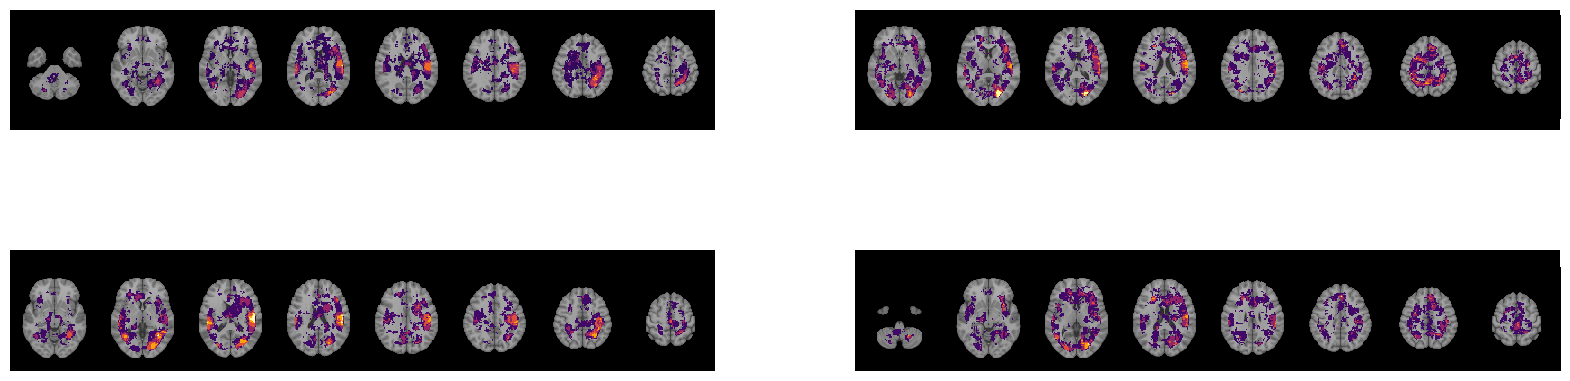

In [ ]:
fig1 = deepcopy(fig)
fig1.subplots_adjust(hspace=1, top=0.8, bottom=0.2)
axes1 = deepcopy(axes)
pad=1
for ax, col in zip(axes[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')
    print(dir(ax))

for ax, row in zip(axes[:,0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')
fig1

In [161]:
fig1 = deepcopy(fig_original)
axes1 = deepcopy(axes_original)

for ax, col in zip(axes[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')
    print(dir(ax))

for ax, row in zip(axes[:,0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')
pad =  0# in points

fig1.subplots_adjust(wspace = 0.1, hspace = 0.1)
plt.figure
plt.show()

import matplotlib.pyplot as plt
from matplotlib import _pylab_helpers


_pylab_helpers.Gcf.set_active(fig1.canvas.manager)
plt.show()



['ArtistList', '_AxesBase__clear', '_PROPERTIES_EXCLUDED_FROM_SET', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_add_text', '_adjustable', '_agg_filter', '_alias_map', '_alpha', '_anchor', '_animated', '_aspect', '_autotitlepos', '_axes', '_axes_locator', '_axis_map', '_axis_names', '_axisbelow', '_box_aspect', '_callbacks', '_check_no_units', '_children', '_clipon', '_clippath', '_cm_set', '_colorbars', '_convert_dx', '_current_image', '_different_canvas', '_errorevery_to_mask', '_facecolor', '_fill_between_process_units', '_fill_between_x_or_y', '_forward_navigation_events', '_frameon', '_fully_clipped_to_axes', '_gci', '_gen_axes_patch',

AttributeError: 'NoneType' object has no attribute 'num'

In [ ]:
for ax, col in zip(axes[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')
    print(dir(ax))

for ax, row in zip(axes[:,0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')
pad =  0# in points



# plt.colorbar(_get_mappable(7), ax=axes, orientation='vertical')
# axes[n, m].title.set_horizontalalignment('left')

plt.subplots_adjust(left = 0.1, wspace = 0.1, hspace = 0.1)
# plt.suptitle(modality, y=1.05)
# fig.tight_layout()
# fig.set_constrained_layout(True)
plt.show()


In [ ]:
axes[0,0].annotate

1

TypeError: Data given cannot be loaded because it is not compatible with nibabel format:
<bound method Base...

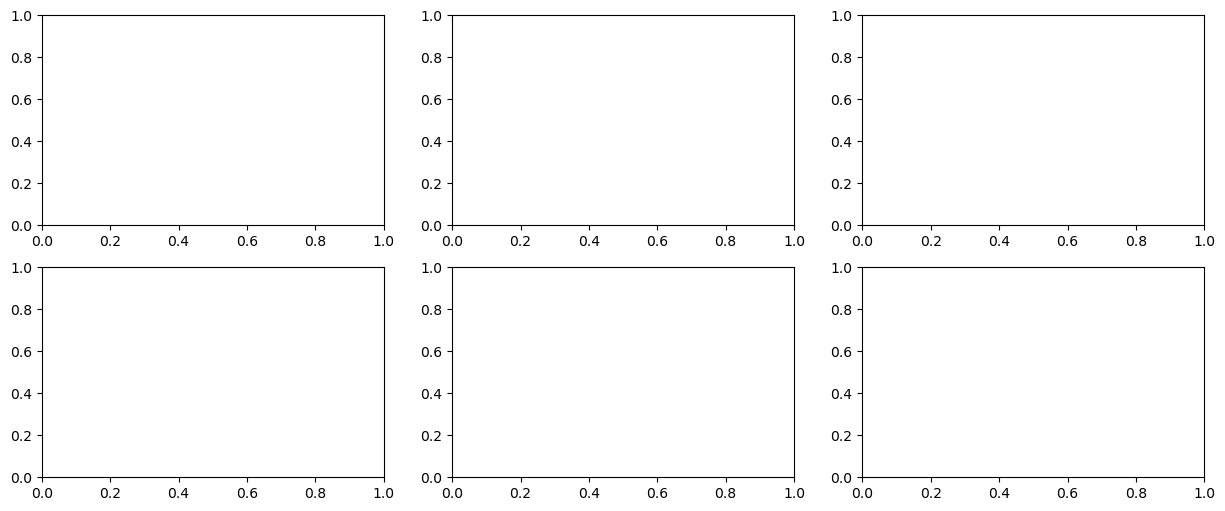

In [31]:
import matplotlib.pyplot as plt

# Create a figure with multiple subplots (2 rows x 3 columns in this example)
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6))
axes = axes.flatten()

# Iterate through your saved displays and replot them into the subplots
for ax, display in zip(axes, displays):
    # Get the data image from the nilearn display object
    img = display._map_show
    plotting.plot_stat_map(
        img,
        display_mode='z',
        cut_coords=8,
        draw_cross=False,
        black_bg=False,
        cmap='inferno',
        colorbar=False,
        axes=ax,
        annotate=False
    )

# Hide any unused subplots
for ax in axes[len(displays):]:
    ax.axis('off')

plt.tight_layout()
plt.show()



In [43]:
dir(figs[0])
# displays[0]._map_show(img=displays[0])

['_PROPERTIES_EXCLUDED_FROM_SET',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_axes_internal',
 '_agg_filter',
 '_align_label_groups',
 '_alpha',
 '_animated',
 '_axobservers',
 '_axstack',
 '_button_pick_id',
 '_callbacks',
 '_canvas_callbacks',
 '_check_layout_engines_compat',
 '_clipon',
 '_clippath',
 '_cm_set',
 '_different_canvas',
 '_dpi',
 '_fully_clipped_to_axes',
 '_gci',
 '_get_dpi',
 '_get_draw_artists',
 '_get_renderer',
 '_gid',
 '_in_layout',
 '_internal_update',
 '_label',
 '_layout_engine',
 '_localaxes',
 '_mouse_key_ids',
 '_mouseover',
 '_norm_per_subplot_kw',
 '_normalize_grid_string',
 '_number',
 '_origi

In [62]:
test = figs[1].get_figure().transSubfigure
test

### 2. Suprasensory

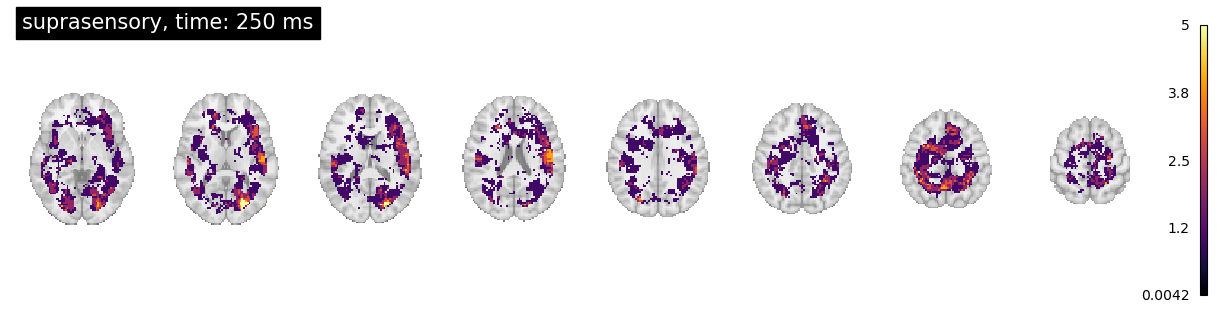

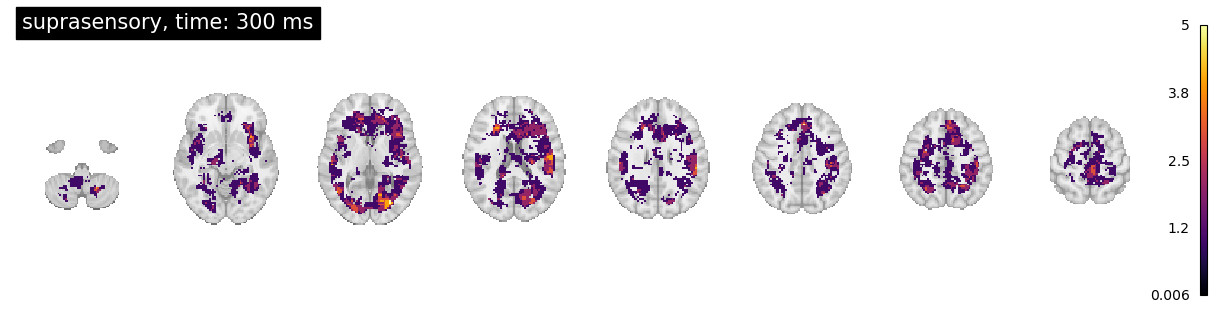

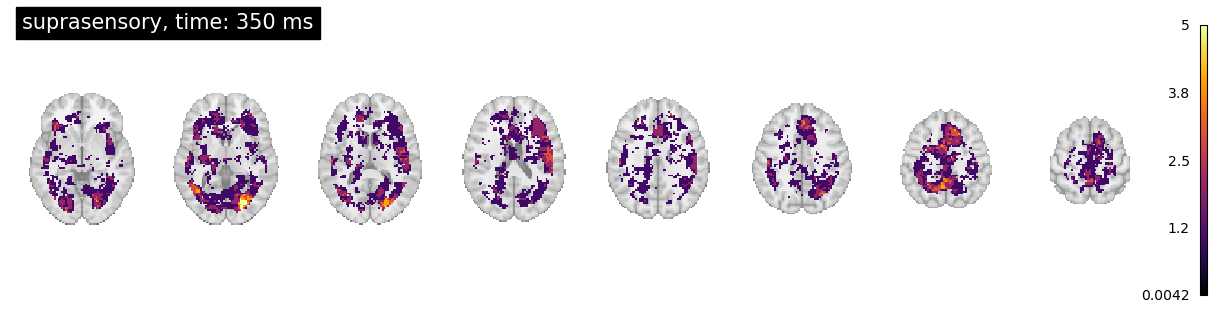

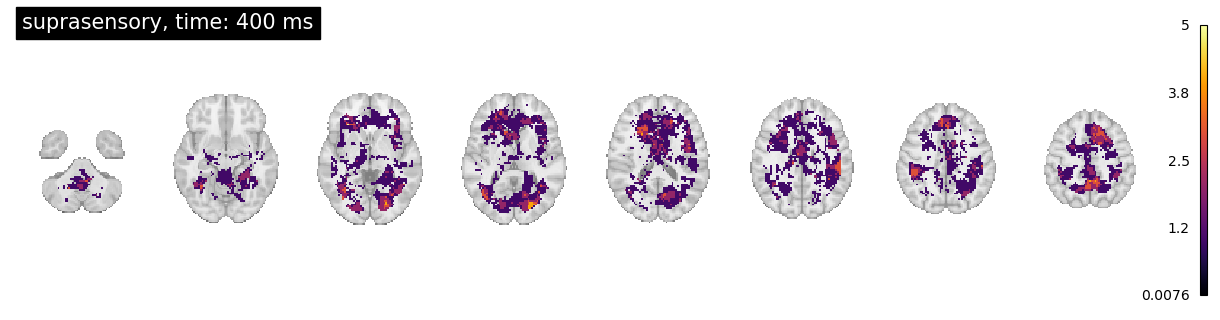

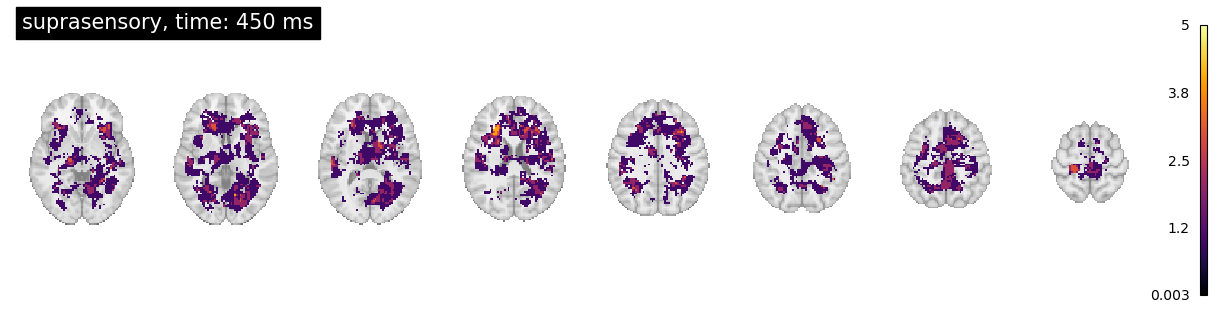

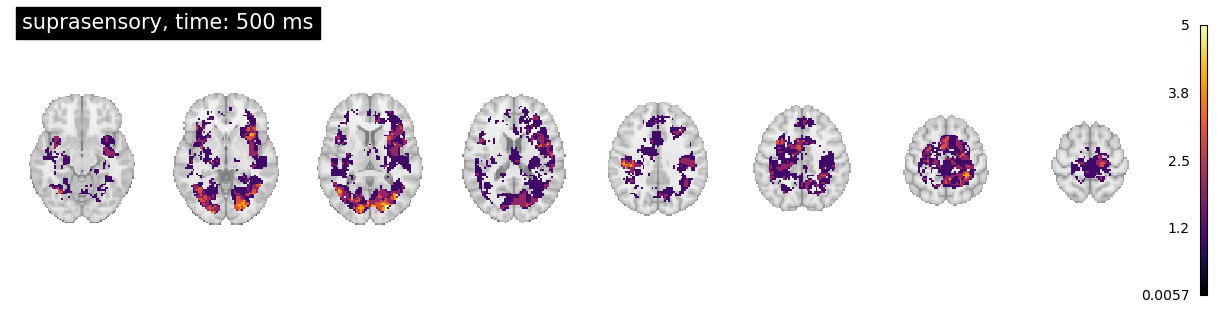

In [5]:
modality = 'suprasensory'  # 'sensory' or 'suprasensory'
thres = 90
time = [125, 130, 135, 140, 145, 150]
mask = nib.load(cfg.maskFile)

for t in time:
    plot_commonality(fusionFiles, modality, thres, t, mask)

## some testing with subplots

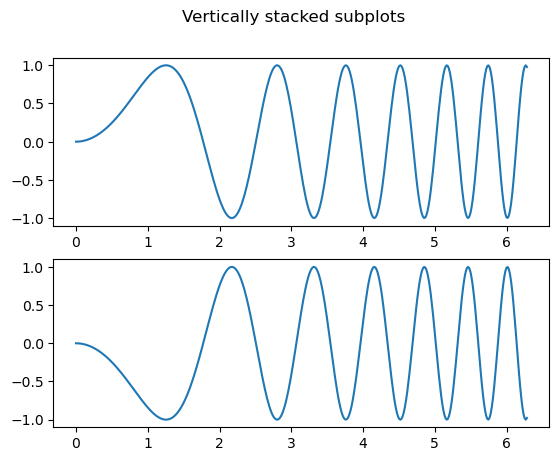

In [25]:
x = np.linspace(0, 2 * np.pi, 400)
y = np.sin(x ** 2)
fig, axs = plt.subplots(2)
fig.suptitle('Vertically stacked subplots')
axs[0].plot(x, y)
axs[1].plot(x, -y)

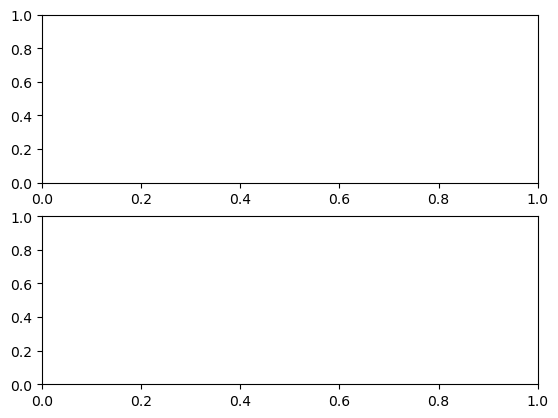

In [28]:
fig, axs = plt.subplots(2)